<a href="https://colab.research.google.com/github/saranya-eng/machine-learning-guest-lecture/blob/main/ML_DT_RF_KNN__Wine1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


| Library / Function     | Where you used it                                                                          | Purpose                                           |
| ---------------------- | ------------------------------------------------------------------------------------------ | ------------------------------------------------- |
| **Pandas (`pd`)**      | `pd.read_csv()`, `df.head()`, `df.describe()`, `df.corr()`                                 | Load and analyze the Wine dataset                 |
| **NumPy (`np`)**       | Imported, but **not directly used** in your current code                                   | Numerical operations; currently not required      |
| **Matplotlib (`plt`)** | `plt.figure()`, `plt.title()`, `plt.xlabel()`, `plt.show()`                                | Create and customize plots                        |
| **Seaborn (`sns`)**    | `sns.countplot()`, `sns.heatmap()`, `sns.histplot()`, `sns.boxplot()`, `sns.scatterplot()` | Create statistical visualizations                 |
| **`train_test_split`** | `train_test_split(X, y, ...)`                                                              | Divide the dataset into training and testing data |
| **`StandardScaler`**   | `StandardScaler()`, `fit_transform()`, `transform()`                                       | Scale features for KNN                            |


**Scikit-learn** is a Python machine learning library.

It provides ready-to-use tools for:

*   Data splitting
*   Feature scaling
*   Machine learning algorithms
*   Model evaluation

You don't separately write or install each algorithm. Scikit-learn provides them as modules.
**Scikit-learn** is commonly described as a machine learning library, while **sklearn** is the package name used in Python.

sklearn                 → Package
   
model_selection         → Module
   
train_test_split        → Function

In [ ]:
# ============================================================
# 1. IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Setting plot style for better visualization
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# 2. LOAD THE DATASET FROM GOOGLE DRIVE
# ============================================================

# Path of the dataset (change if needed)
file_path = '/content/drive/MyDrive/wine/wine.data'

In [ ]:
# Column names of the Wine dataset
column_names = [
    'Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash',
    'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
    'Proanthocyanins', 'Color_intensity', 'Hue',
    'OD280_OD315_of_diluted_wines', 'Proline'
]

# Loading the dataset
# header=None: The dataset file does not have a header row
df = pd.read_csv(file_path, header=None, names=column_names)

print("Dataset loaded successfully!")
print("Shape of the dataset:", df.shape) # df is a Pandas DataFrame object, and shape is an attribute of the df object.
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.head(10)


Dataset loaded successfully!
Shape of the dataset: (178, 14)
Number of rows: 178
Number of columns: 14


,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [ ]:
print(df.columns.tolist()) # df.columns.tolist() returns all column names as a Python list.

['Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280_OD315_of_diluted_wines', 'Proline']


The main purpose of **EDA **(**Exploratory Data Analysis**) is:

To understand the dataset before building a machine learning model.

You are basically asking: What data do I have? Is it clean? What does it look like? Are there any problems?
| Code                         | What you are checking            | Why?                                        |
| ---------------------------- | -------------------------------- | ------------------------------------------- |
| `df.info()`                  | Dataset structure and data types | Understand columns, rows, and data types    |
| `df.isnull().sum()`          | Missing values                   | Check whether data is incomplete            |
| `df['Class'].value_counts()` | Class distribution               | Check how many samples belong to each class |
| `df.describe()`              | Statistical summary              | Understand the numerical features           |


In [ ]:
# ============================================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['Class'].value_counts())

print("\nStatistical Summary:")
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic_acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total_phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280_OD315_of_diluted_wines  178 non-null    flo

,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


**Statistical analysis** helps us decide what preprocessing may be needed.  

Min + Max → Range: How low and how high can the feature values go?

Mean → Center: What is the average/typical value?

Std → Spread: How much do the values vary around the average?

Together → Data understanding: They help us identify scale differences and possible unusual values, which guide our preprocessing decisions.

**In our Wine dataset**:

Proline has values ranging from 278 to 1680, while Alcohol ranges only from 11.03 to 14.83.

So the features are on very different scales. Because their scales are very different, we may need feature scaling .

Then we can choose either:

**Min-Max Scaling** → transforms values to a fixed range, usually 0 to 1

**Standardization (Z-score)** → transforms values based on their mean and standard deviation



4. DATA VISUALIZATION
Here we are doing two visualizations as part of EDA. The main purpose is to understand the **data visually instead of looking only at numbers.**

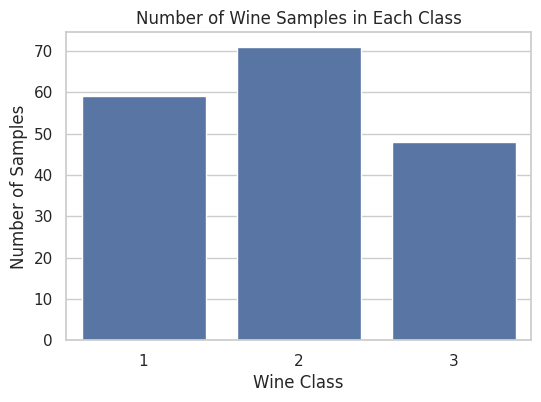

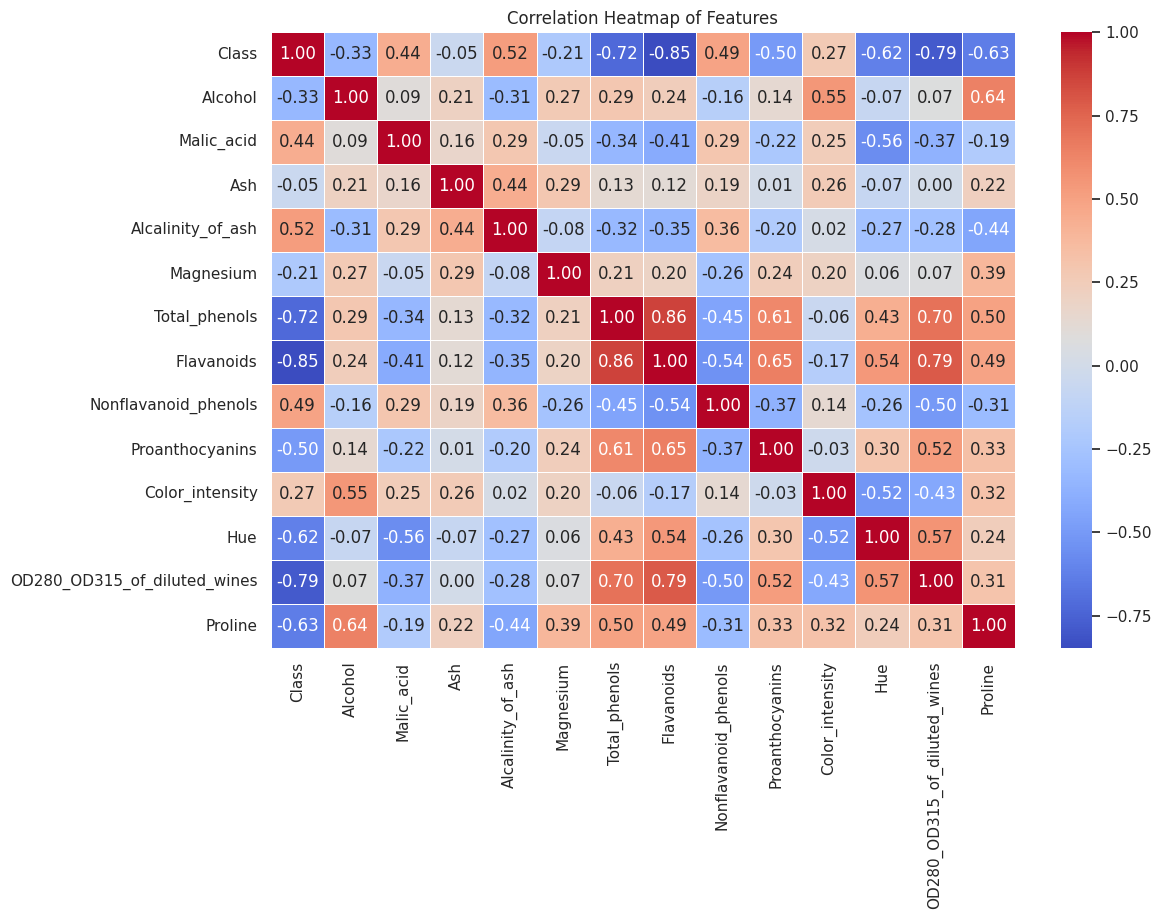

In [ ]:
# ============================================================
# 4. DATA VISUALIZATION
# ============================================================

# Class Distribution
# Creates the figure and specifies its size.
plt.figure(figsize=(6, 4))
#Counts the number of samples in each Class and displays them as bars.
sns.countplot(x='Class', data=df)
plt.title('Number of Wine Samples in Each Class')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

## Correlation Heatmap

A correlation heatmap helps us understand the **linear relationship between numerical variables** in the dataset. It tells us **how two variables are related to each other**.

### Code Explanation

`df.corr()` → Calculates the correlation between numerical columns.

Correlation values range from **-1 to +1**:

- **+1** → Strong positive relationship
- **0** → No linear relationship
- **-1** → Strong negative relationship

`sns.heatmap()` → Represents these correlation values visually using colors.

- `annot=True` → Displays the correlation value inside each cell.
- `fmt='.2f'` → Displays the values up to 2 decimal places.
- `cmap='coolwarm'` → Uses different colors to represent positive and negative correlations.
- `linewidths=0.5` → Adds lines between cells for better readability.

### Why do we perform correlation analysis?

It helps us identify:

- Which features have a strong relationship with each other
- Which features have a weak relationship
- Possible redundant or highly related features
- Patterns that may be useful during feature analysis

### **Important**

Correlation tells us how two variables are related to each other.

The correlation value is always between −1 and +1:

Correlation	Meaning
+1	Perfect positive relationship
0	No linear relationship
−1	Perfect negative relationship

Think of it like this:

Positive (+) → both tend to move in the same direction

Alcohol ↑ → Proline tends to ↑

Negative (−) → they tend to move in opposite directions

Flavanoids ↑ → Class tends to ↓

Near 0 → little/no linear relationship

| **Relationship**      | **What are we looking for?**                 | **Why?**                                                                                                      |
| --------------------- | -------------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **Feature ↔ Target**  | **Strong relationship/association**          | May indicate that the feature contains **useful information for predicting the target**.                      |
| **Feature ↔ Feature** | **Very strong correlation between features** | May indicate **redundant/similar information** between features, so we may investigate **feature selection**. |
| **Feature ↔ Feature** | **Low correlation between features**         | Features are **less likely to be redundant** and may provide **complementary/different information**.         |


**Alcohol × Proline**
You see: 0.64 (That means Alcohol and Proline have a moderately strong positive correlation.)

🔴 Red/orange → positive correlation

🔵 Blue → negative correlation

⚪ Light/neutral → correlation close to zero

**Look at the heatmap:** And the darker the color, the stronger the correlation. Why is everything on the diagonal 1.00?
Because we are comparing a feature with itself. so we need to focus on non diagonal values.
| **What we find**                                       | **What it tells us**                                                   | **Why is it useful?**                                               | **Example from your heatmap**                                          |
| ------------------------------------------------------ | ---------------------------------------------------------------------- | ------------------------------------------------------------------- | ---------------------------------------------------------------------- |
| 🔴 **Strong positive correlation**                     | Two features tend to increase/decrease together                        | They may contain **similar or overlapping information**             | **Total_phenols ↔ Flavanoids = +0.86** → strong positive relationship  |
| 🔵 **Strong negative correlation**                     | When one feature increases, the other tends to decrease                | Shows an important **opposite relationship**                        | **Class ↔ Flavanoids = −0.85** → strong negative association           |
| ⚪ **Weak/near-zero correlation**                       | There is little or no **linear relationship** between the two features | Suggests the features are behaving relatively independently         | **Ash ↔ Hue = −0.07** → very weak relationship                         |
| 🔴🔵 **Strong correlation between two input features** | The two features may provide **redundant information**                 | Helps us investigate **feature selection/reduction**                | **Total_phenols ↔ Flavanoids = +0.86** → possible redundancy           |
| 🎯 **Strong correlation with target**                  | A feature has a strong association with the target                     | Can help us identify features that **may be useful for prediction** | **Class ↔ Flavanoids = −0.85** → strong association with encoded Class |



In [ ]:
# print(df['Class'].value_counts())

**HIstogram**: A histogram is a graph used to show the distribution of numerical data.
"First, I want to understand how the **Alcohol values are distributed across all wine samples**."

X-axis (Alcohol): Shows the alcohol content of the wine, approximately from 11% to 15%.
Y-axis (Frequency): Shows the number of wines that fall within each alcohol-value range.
What the graph tells us: Most wines have alcohol content between 12% and 14%, with the highest concentration around 13–13.5%.

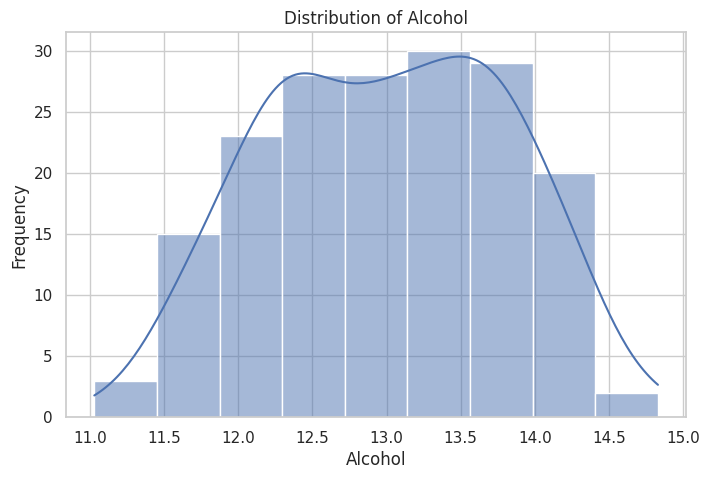

In [ ]:
# ============================================================
# a)Feature distributions
# ============================================================
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Alcohol', kde=True)

plt.title('Distribution of Alcohol')
plt.xlabel('Alcohol')
plt.ylabel('Frequency')

plt.show()

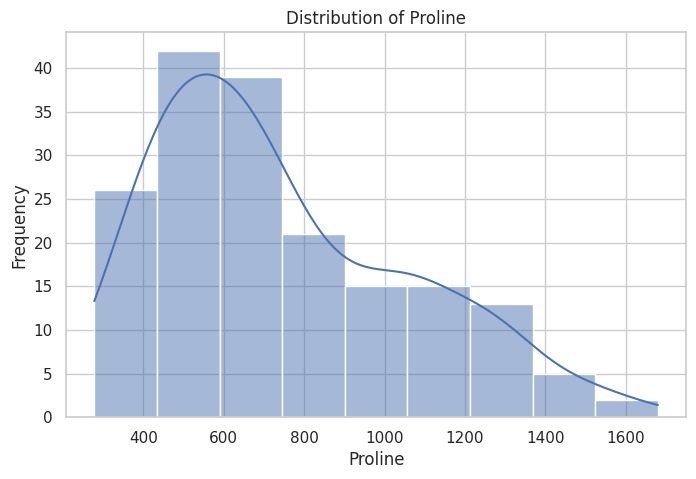

In [ ]:
# ============================================================
# b) Feature distributions
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Proline', kde=True)

plt.title('Distribution of Proline')
plt.xlabel('Proline')
plt.ylabel('Frequency')

plt.show()

A **scatter plot** is a graph used to show the **relationship between two numerical features. **
Before giving data to the machine-learning algorithm, we visualize it to see whether the features contain patterns that can help us distinguish the classes

 X-axis (Alcohol): Shows the alcohol content of each wine.

Y-axis (Flavanoids): Shows the flavanoid content of each wine.

What the graph tells us: The three wine classes form different clusters, showing that Alcohol and Flavanoids can help distinguish the wine classes.

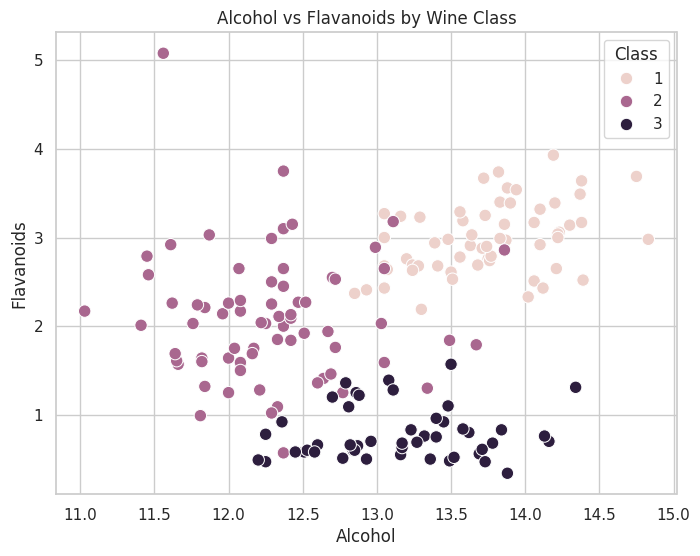

In [ ]:
# ============================================================
# f) scatter plot
# Take two features:Alcohol vs Flavanoids
# ============================================================
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Alcohol',
    y='Flavanoids',
    hue='Class',
    s=80
)

plt.title('Alcohol vs Flavanoids by Wine Class')
plt.xlabel('Alcohol')
plt.ylabel('Flavanoids')

plt.show()

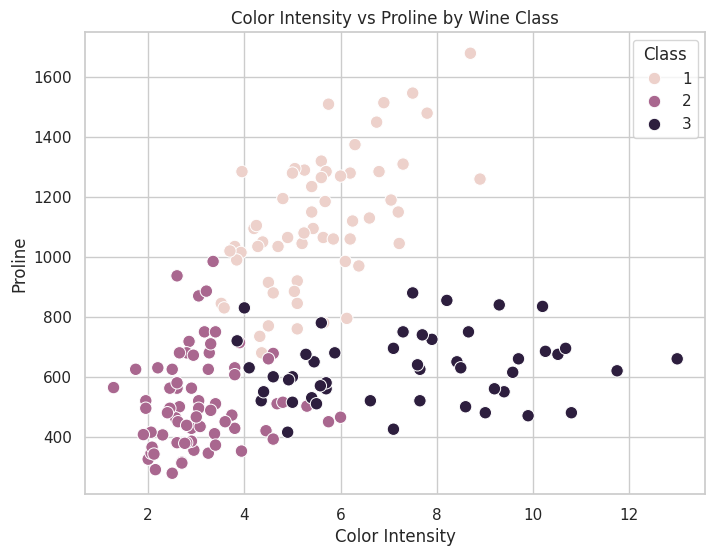

In [ ]:
# ============================================================
# g) scatter plot
# Take two features:Color_intensity vs Proline
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Color_intensity',
    y='Proline',
    hue='Class',
    s=80
)

plt.title('Color Intensity vs Proline by Wine Class')
plt.xlabel('Color Intensity')
plt.ylabel('Proline')

plt.show()

## 5. PREPROCESSING

Before applying a Machine Learning algorithm, we prepare the data for training.

### 🔹 Step 1: Separate Features and Target

- **X (Features):** Contains the input features used to make predictions.
- **y (Target):** Contains the `Class` column that we want the model to predict.
- We remove `Class` from X because it is the **target**, not an input feature.

---

### 🔹 Step 2: Split the Data into Training and Testing Sets

We divide the dataset into:

- **80% Training Data** → used to train the ML model.
- **20% Testing Data** → used to evaluate the model on unseen data.
- `random_state=42` → ensures we get the same split every time.
- `stratify=y` → maintains a similar proportion of each wine class in both training and testing data.

---

### 🔹 Step 3: Feature Scaling

Different features can have very different numerical ranges.

For example:
- **Alcohol** → approximately 11–15
- **Magnesium** → approximately 70–162

If we directly give these values to some ML algorithms, features with larger numerical values may have more influence.

Therefore, we use **StandardScaler**.

### 📌 What is StandardScaler?

`StandardScaler` is a preprocessing technique that **standardizes numerical features** so that they have:

- **Mean ≈ 0**
- **Standard deviation ≈ 1**

The formula used is:

**z = (x − mean) / standard deviation**

So, it changes the scale of the features while preserving the information in the data.

---

### 🔹 Step 4: fit_transform()

```python
X_train_scaled = scaler.fit_transform(X_train)

**fit_transform(X_train):**
fit() → Learns the mean and standard deviation from the training data.
transform() → Uses those learned values to scale the training data.
fit_transform() = Learn + Scale

**transform()** :
Uses the mean and standard deviation already learned from training data to scale the test data.

transform() = Scale using what was already learned

**What are X_train, X_test, y_train, y_test?**
| Variable    | Meaning                 | Contains                                 |
| ----------- | ----------------------- | ---------------------------------------- |
| **X_train** | Training input features | Features used to train the model         |
| **X_test**  | Testing input features  | Features given to the model for testing  |
| **y_train** | Training target         | Correct classes corresponding to X_train |
| **y_test**  | Testing target          | Actual classes used to check predictions |


```
# This is formatted as code
```



In [ ]:
# ============================================================
# 5. PREPROCESSING
# ============================================================

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing completed successfully!")

Training set shape: (142, 13)
Testing set shape : (36, 13)

Preprocessing completed successfully!


| Algorithm                 | Impurity / Basis   | Split Selection                                         |
| ------------------------- | ------------------ | ------------------------------------------------------- |
| **ID3**                   | **Entropy**        | **Information Gain**                                    |
| **C4.5**                  | **Entropy**        | **Gain Ratio**                                          |
| **CART – Classification** | **Gini Impurity**  | Choose split with lowest weighted Gini                  |
| **CART – Regression**     | **Variance / MSE** | Choose split that minimizes impurity / reduces variance |
| **C5.0**                  | **Entropy**        | **Gain Ratio**                                          |


## Decision Tree Classification

**Tree Used:** Decision Tree Classifier (CART-based)

**Splitting Criterion:** Entropy (Information Gain)

**Maximum Depth:** Not specified (`max_depth=None`) — the tree grows until other stopping conditions are reached.

**Problem Type:** Multiclass Classification

**Target:** Wine Class (Class 1, Class 2, Class 3)

In [ ]:
# ============================================================
# 6. DECISION TREE CLASSIFICATION
# ============================================================

from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# ============================================================
# 6. DECISION TREE CLASSIFICATION : CART-based Decision Tree + Entropy (Information Gain) + max_depth=None.
# ============================================================

from sklearn.tree import DecisionTreeClassifier

# Create the CART-based Decision Tree model
# criterion='entropy' → uses entropy / information gain
# max_depth is not specified → default is None

dt_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


## Step 7: Make Predictions

Now that the Decision Tree has been trained, we use the **test data** to make predictions.

- `X_test` contains the wine samples that the model has not seen during training.
- `dt_model.predict()` uses the trained Decision Tree to predict the wine class.
- The predicted results are stored in `y_pred`.

### Practical Idea

**Trained Model + Test Features → Predicted Classes**

We will compare these predictions with the actual test labels (`y_test`) in the next step to measure how well our model performs.

In [ ]:
# ============================================================
# 7. MAKE PREDICTIONS
# ============================================================

# Predict the classes for the test data
y_pred = dt_model.predict(X_test)

print("Predictions completed successfully!")
print("Predicted classes:", y_pred)

Predictions completed successfully!
Predicted classes: [1 2 1 2 2 1 1 2 2 3 2 3 1 3 1 2 2 1 2 1 2 2 1 1 2 2 1 3 2 3 1 3 2 3 3 3]


## Step 8: Evaluate the Model

Now we compare the **predicted classes (`y_pred`)** with the **actual classes (`y_test`)**.

This helps us understand how well the Decision Tree classifies unseen wine samples.

We will use:
- **Accuracy** – overall percentage of correct predictions
- **Confusion Matrix** – shows correct and incorrect predictions for each class
- **Classification Report** – provides precision, recall, and F1-score

In [ ]:
# ============================================================
# 8. MODEL EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)
print("Decision Tree Accuracy: {:.2f}%".format(accuracy * 100))

Decision Tree Accuracy: 0.9722222222222222
Decision Tree Accuracy: 97.22%


## Confusion Matrix

Accuracy tells us the overall percentage of correct predictions.

The **Confusion Matrix** gives a more detailed view by showing how many samples were:
- Correctly classified for each class
- Misclassified into another class

For our Wine dataset, we have three classes: **1, 2, and 3**.

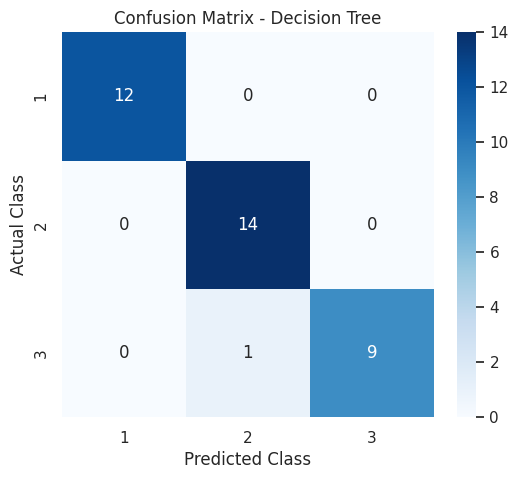

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

## Step 10: Classification Report

The classification report provides detailed performance measures for each wine class.

It includes:

- **Precision** – How many of the samples predicted as a class were actually that class.
- **Recall** – How many of the actual samples of a class were correctly identified.
- **F1-score** – Balance between precision and recall.
- **Support** – Number of actual samples belonging to each class.

In [ ]:
# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## Step 11: Visualize the Decision Tree

The Decision Tree has learned a set of decision rules from the training data.

We can visualize the trained tree to understand:

- Which features are selected for splitting
- The threshold used for each split
- How the data moves through the branches
- The final predicted class at each leaf

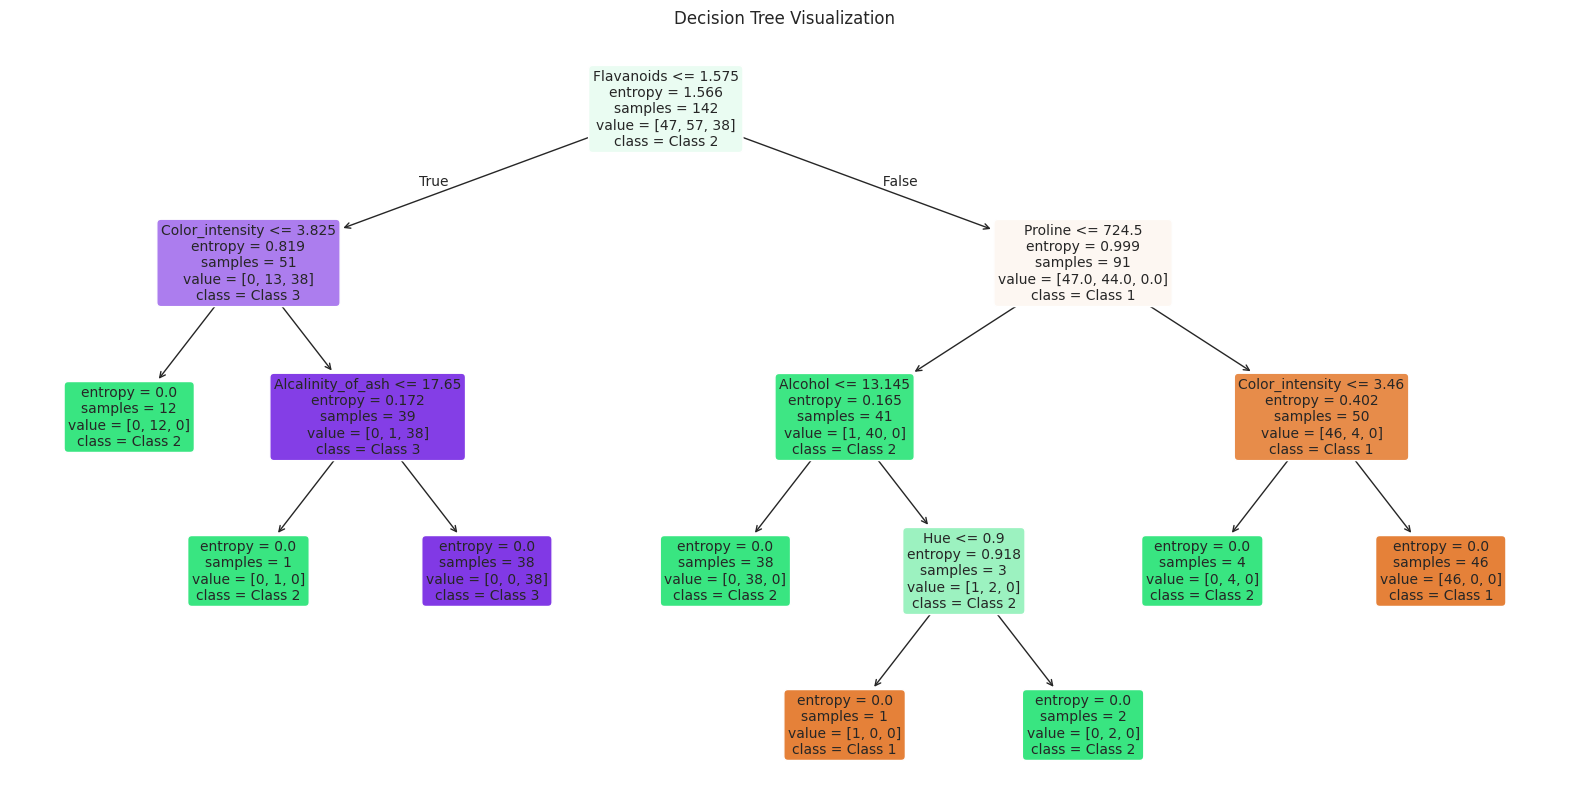

In [ ]:
# ============================================================
# 11. VISUALIZE THE DECISION TREE
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Class 1', 'Class 2', 'Class 3'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

## Step 12: Random Forest Classification

**Random Forest** is an ensemble learning algorithm that combines multiple Decision Trees to make a final prediction.

Instead of relying on a single Decision Tree, Random Forest:
- Builds multiple Decision Trees
- Uses different subsets of the training data and features
- Combines the predictions of all trees
- Uses majority voting for classification

**Problem Type:** Multiclass Classification

**Target:** Wine Class (Class 1, Class 2, Class 3)

In [ ]:
# ============================================================
# 12. RANDOM FOREST CLASSIFICATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Step 13: Make Predictions

Now that the Random Forest has been trained, we use the **test data** to predict the wine classes.

- `X_test` contains unseen wine samples.
- `rf_model.predict()` uses all the trees in the Random Forest to make predictions.
- The final prediction is based on **majority voting** among the individual Decision Trees.
- The predicted classes are stored in `y_pred_rf`.

In [ ]:
# ============================================================
# 13. MAKE PREDICTIONS - RANDOM FOREST
# ============================================================

# Predict the classes for the test data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed successfully!")
print("Predicted classes:", y_pred_rf)

Random Forest predictions completed successfully!
Predicted classes: [1 3 1 2 2 1 1 2 2 3 2 3 1 3 1 2 2 1 2 1 2 2 1 1 2 2 1 3 2 3 1 3 2 3 3 3]


## Step 14: Evaluate Random Forest – Accuracy

Accuracy tells us the overall percentage of test samples that the Random Forest classified correctly.

We compare:
- `y_test` → Actual wine classes
- `y_pred_rf` → Predicted wine classes

Higher accuracy indicates better overall classification performance.

In [ ]:
# ============================================================
# 14. RANDOM FOREST - ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy: {:.2f}%".format(rf_accuracy * 100))

Random Forest Accuracy: 1.0
Random Forest Accuracy: 100.00%


## Step 15: Confusion Matrix – Random Forest

The confusion matrix shows how the Random Forest classified the test samples for each wine class.

It helps us identify:
- Correct predictions for each class
- Incorrect predictions between different classes

For our Wine dataset, we have three classes: Class 1, Class 2, and Class 3.

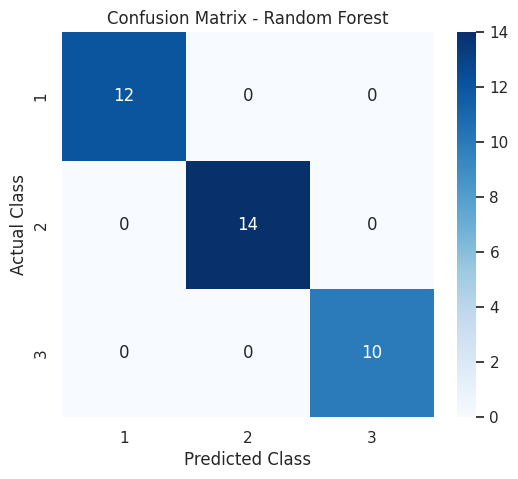

In [ ]:
# ============================================================
# 15. RANDOM FOREST - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Display confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## Step 16: Classification Report – Random Forest

The classification report provides detailed performance measures for each wine class.

It includes:

- **Precision** – How many of the samples predicted as a class were actually that class.
- **Recall** – How many of the actual samples of a class were correctly identified.
- **F1-score** – Balance between precision and recall.
- **Support** – Number of actual samples belonging to each class.

In [ ]:
# ============================================================
# 16. RANDOM FOREST - CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

# Generate classification report
rf_report = classification_report(y_test, y_pred_rf)

print("Random Forest Classification Report:")
print(rf_report)

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Step 17: Visualize a Sample Tree from Random Forest

A Random Forest contains multiple Decision Trees.

Our Random Forest contains **100 trees**.

We can visualize one or more individual trees to understand how the trees make decisions.

Here, we visualize the **first tree** from the Random Forest.

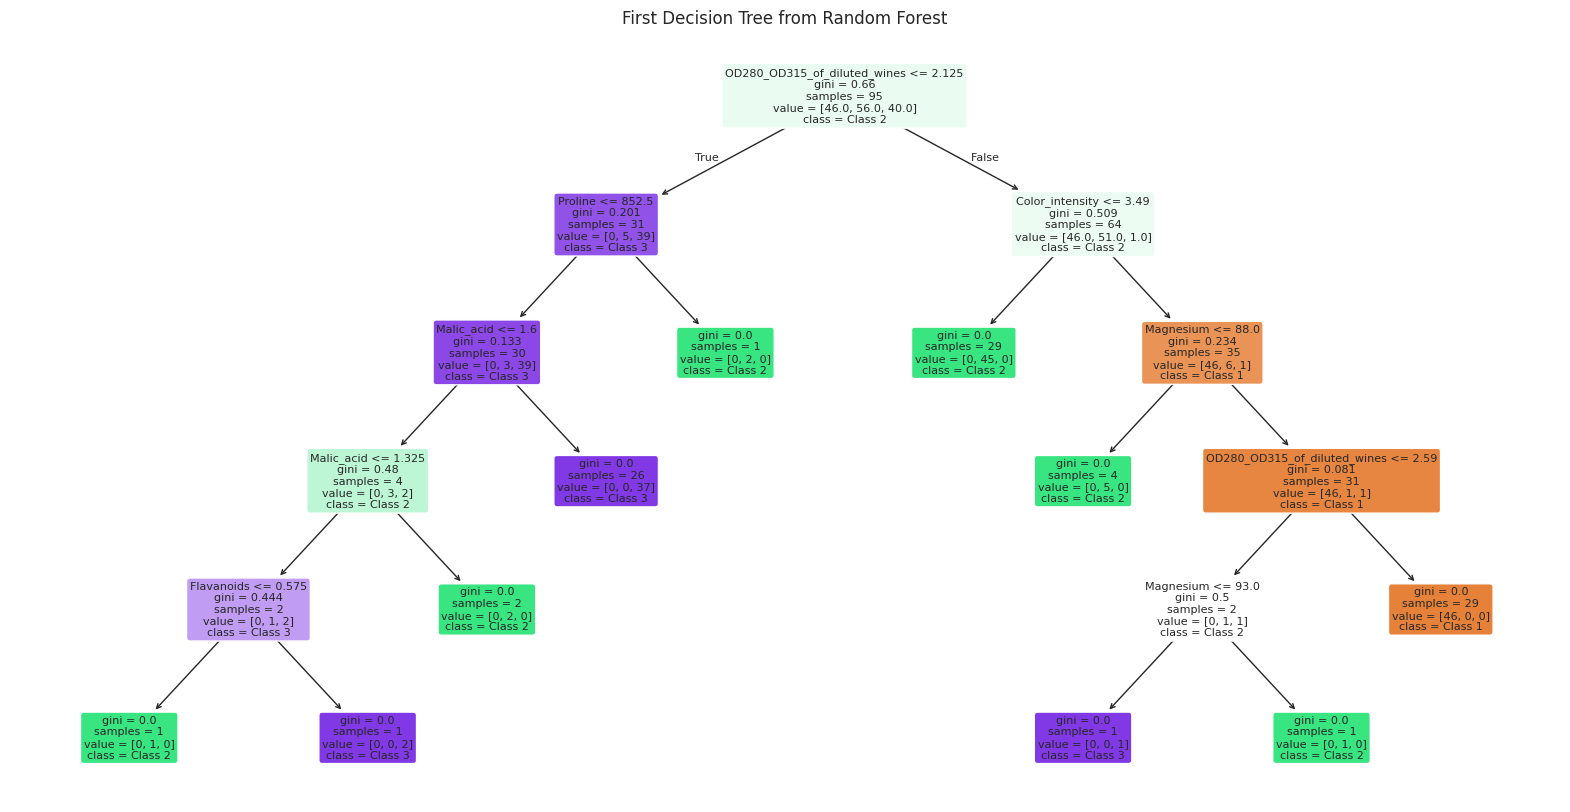

In [ ]:
# ============================================================
# 17. VISUALIZE ONE TREE FROM RANDOM FOREST
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=['Class 1', 'Class 2', 'Class 3'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("First Decision Tree from Random Forest")
plt.show()

In [ ]:
# Number of trees in the Random Forest
print("Number of trees:", len(rf_model.estimators_))

Number of trees: 100


## Step 18: K-Nearest Neighbors (KNN) Classification

KNN classifies a new data point based on its nearest neighboring data points.

For our Wine dataset:

- **Problem Type:** Multiclass Classification
- **Target:** Wine Class (Class 1, Class 2, Class 3)
- **Number of Neighbors (K):** 5
- **Distance Measure:** Euclidean Distance
- **Feature Scaling:** Already performed

In [ ]:
# ============================================================
# 18. TRAIN KNN MODEL
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model using scaled training data
knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


## Step 19: Make Predictions

Now that the KNN model has been trained, we use the **test data** to predict the wine classes.

- `X_test_scaled` contains the scaled test samples.
- `knn_model.predict()` finds the nearest neighbors for each test sample.
- The majority class among the nearest neighbors is selected as the prediction.
- The predicted classes are stored in `y_pred_knn`.

In [ ]:
# ============================================================
# 19. MAKE PREDICTIONS - KNN
# ============================================================

# Predict the classes for the test data
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN predictions completed successfully!")
print("Predicted classes:", y_pred_knn)

KNN predictions completed successfully!
Predicted classes: [1 3 1 2 2 1 1 2 2 3 2 3 1 3 1 2 2 1 2 1 2 2 1 1 2 2 1 3 3 3 1 3 2 3 3 3]


## Step 20: Evaluate KNN – Accuracy

Now we compare the **predicted classes (`y_pred_knn`)** with the **actual classes (`y_test`)**.

Accuracy tells us the overall percentage of test samples that the KNN model classified correctly.

A higher accuracy indicates better overall classification performance.

In [ ]:
# ============================================================
# 20. KNN - ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("KNN Accuracy: {:.2f}%".format(knn_accuracy * 100))

KNN Accuracy: 0.9722222222222222
KNN Accuracy: 97.22%


## Step 21: Confusion Matrix – KNN

The confusion matrix shows how the KNN model classified the test samples for each wine class.

It helps us identify:
- Correct predictions for each class
- Incorrect predictions between different classes

For our Wine dataset, we have three classes: Class 1, Class 2, and Class 3.

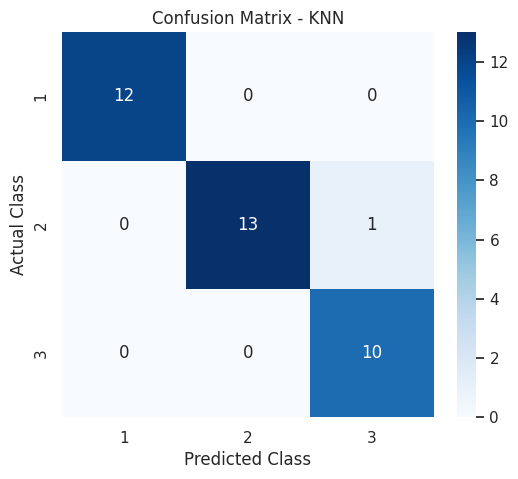

In [ ]:
# ============================================================
# 21. KNN - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix - KNN')
plt.show()

## Step 22: Classification Report – KNN

The classification report provides detailed performance measures for each wine class.

It includes:

- **Precision** – How many of the samples predicted as a class were actually that class.
- **Recall** – How many of the actual samples of a class were correctly identified.
- **F1-score** – Balance between precision and recall.
- **Support** – Number of actual samples belonging to each class.

In [ ]:
# ============================================================
# 22. KNN - CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

knn_report = classification_report(y_test, y_pred_knn)

print("KNN Classification Report:")
print(knn_report)

KNN Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      0.93      0.96        14
           3       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## Step 23: Compare Model Performance

We have trained and evaluated three classification models:

1. Decision Tree
2. Random Forest
3. K-Nearest Neighbors (KNN)

Now we compare their **accuracy** on the same test dataset.

This helps us understand which model performed better for our Wine dataset.

In [ ]:
# ============================================================
# 23. COMPARE MODEL ACCURACY
# ============================================================

print("Model Performance Comparison")
print("--------------------------------")

print("Decision Tree  : {:.2f}%".format(accuracy * 100))
print("Random Forest  : {:.2f}%".format(rf_accuracy * 100))
print("KNN            : {:.2f}%".format(knn_accuracy * 100))

# Find the best model
model_accuracies = {
    "Decision Tree": accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy
}

best_model = max(model_accuracies, key=model_accuracies.get)

print("\nBest Performing Model:", best_model)

Model Performance Comparison
--------------------------------
Decision Tree  : 97.22%
Random Forest  : 100.00%
KNN            : 97.22%

Best Performing Model: Random Forest


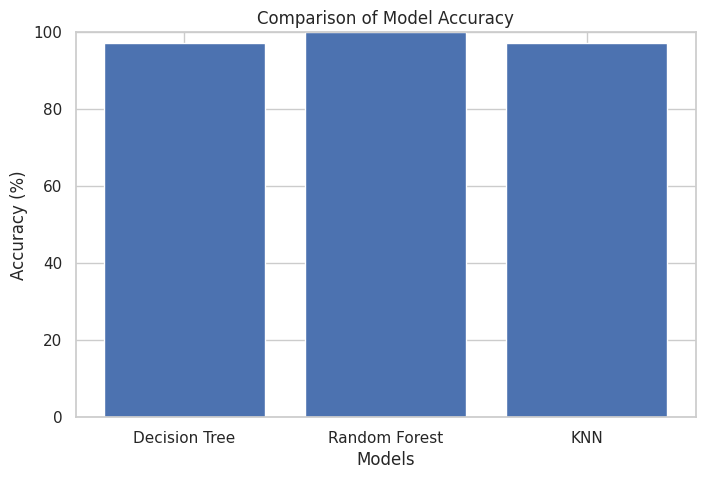

In [ ]:
# ============================================================
# 24. VISUAL COMPARISON OF MODEL ACCURACY
# ============================================================

models = ['Decision Tree', 'Random Forest', 'KNN']
accuracies = [
    accuracy * 100,
    rf_accuracy * 100,
    knn_accuracy * 100
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Model Accuracy')
plt.ylim(0, 100)

plt.show()